# Notebook 07: Ethics & Explainability

**Purpose:** Demonstrate non-discrimination to the Bank of Ghana using:
1. SHAP explanations for individual decisions
2. Disparate Impact Ratio analysis (the 80% rule)
3. Equalized Odds check
4. Formal compliance report

## Ethical Framework

**Disparate Treatment** (direct discrimination): using a protected attribute directly in decisions.  
→ Prevented by EXCLUDING ethnic_group, owner_gender, disability_status from model features.

**Disparate Impact** (indirect discrimination): a facially neutral policy that disproportionately harms a protected group.  
→ Detected by comparing approval rates across groups (Disparate Impact Ratio).  
→ Can occur even without intent — requires monitoring, not just prevention.

**SHAP Explainability**: Required to answer "why was this loan declined?" — a regulatory right in many jurisdictions and a customer service requirement.

## Key Principle
The goal is not a perfect model — it is a *fair, explainable, monitored* model. A model with a known disparity that is documented and under active remediation is more compliant than a model with an unknown disparity.

In [1]:
# ── CELL 1: Environment setup ──────────────────────────────────────────────────
import sys, os, json

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/stanbic_sme_credit'
except ImportError:
    IN_COLAB = False
    _search = os.getcwd()
    BASE_PATH = _search
    for _ in range(3):
        if os.path.isdir(os.path.join(BASE_PATH, 'src')):
            break
        BASE_PATH = os.path.dirname(BASE_PATH)

sys.path.insert(0, os.path.join(BASE_PATH, 'src'))
env_str = 'Google Colab' if IN_COLAB else 'Local Jupyter'
print(f'Environment : {env_str}')
print(f'Base path   : {BASE_PATH}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from fairness import FairnessAuditor
from preprocessing import NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES, TARGET

PROCESSED    = f'{BASE_PATH}/data/processed'
MODELS_PATH  = f'{BASE_PATH}/models'
FIGURES_PATH = f'{BASE_PATH}/reports/figures'
print('Environment ready. shap version:', shap.__version__)

Mounted at /content/drive
Environment : Google Colab
Base path   : /content/drive/MyDrive/stanbic_sme_credit
Environment ready. shap version: 0.51.0


In [2]:
# ── CELL 2: Load all required data ────────────────────────────────────────────
import numpy as np
X_train = pd.read_csv(f'{PROCESSED}/X_train.csv', index_col=0)
X_test  = pd.read_csv(f'{PROCESSED}/X_test.csv',  index_col=0)
y_test  = pd.read_csv(f'{PROCESSED}/y_test.csv',  index_col=0).squeeze('columns')
y_prob  = pd.read_csv(f'{PROCESSED}/y_prob_test.csv', index_col=0).squeeze('columns')

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf],  np.nan, inplace=True)

fair_train = pd.read_csv(f'{PROCESSED}/fair_train.csv', index_col=0)
fair_test  = pd.read_csv(f'{PROCESSED}/fair_test.csv',  index_col=0)

decisions_df = pd.read_csv(f'{PROCESSED}/decisions_test.csv')

with open(f'{MODELS_PATH}/model_registry.json') as f:
    registry = json.load(f)

winning_model_name = registry.get('winning_model', 'logistic_regression_v1')
winning_model = joblib.load(f'{MODELS_PATH}/{winning_model_name}.pkl')

# For SHAP: we need a single sklearn Pipeline (TreeExplainer or LinearExplainer).
# If the winning model is the Stacking ensemble, use the LightGBM base model
# for SHAP explanations — it is the strongest tree model in the stack and its
# predictions are the primary driver of the ensemble.
# WHY not explain the stacking directly: StackingClassifier is a meta-model
# whose meta-features are cross-fitted OOF probabilities. KernelExplainer could
# handle it but is O(n^2) slow on 600 test rows. TreeExplainer on the base tree
# model is exact, fast, and produces interpretable per-feature attributions.
if 'stacking' in winning_model_name.lower():
    # Extract LGBM base estimator from stacking
    try:
        shap_model = winning_model.named_estimators_['lgbm']
        shap_model_name = 'LightGBM (base model from Stacking Ensemble)'
    except (KeyError, AttributeError):
        # Fallback: load LGBM directly
        shap_model = joblib.load(f'{MODELS_PATH}/lightgbm_v1.pkl')
        shap_model_name = 'LightGBM (loaded separately)'
    print(f'Winning model: {winning_model_name}')
    print(f'SHAP explainer: {shap_model_name}')
    print('NOTE: SHAP uses LightGBM base model for exact TreeExplainer values.')
    print('      The Stacking ensemble amplifies LightGBM predictions — SHAP')
    print('      values remain accurate for feature attribution and regulatory audit.')
else:
    shap_model = winning_model
    shap_model_name = winning_model_name

print(f'\nTest decisions loaded: {len(decisions_df):,}')
print(f'Fairness columns: {list(fair_test.columns)}')



Test decisions loaded: 608
Fairness columns: ['ethnic_group', 'owner_gender', 'disability_status', 'owner_gender_clean']


## Part 1: SHAP Explainability

### Why SHAP over other methods?

| Method | Limitation |
|--------|----------|
| Feature importance (built-in) | Global average only — cannot explain individual decisions |
| LIME | Local approximation — not guaranteed to be consistent or accurate |
| **SHAP** | **Exact (TreeExplainer), theoretically grounded (game theory), additive, consistent** |

**SHAP values add up to exactly:**
`f(x) - E[f(x)]` = (actual prediction) - (average prediction)

This additive property means: "This borrower's 0.65 default probability = 0.15 average + 0.30 (credit score contribution) + 0.12 (DPD contribution) + ... "

Each term is auditable and explainable to a non-technical audience.

In [3]:
# ── CELL 3: Build SHAP explainer ──────────────────────────────────────────────
# TargetEncoder (v2 preprocessor) preserves one column per categorical feature,
# so feature names are simply: NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES.
# This replaces the previous OHE-based get_feature_names_out() logic.

preprocessor = shap_model.named_steps['preprocessor']
classifier   = shap_model.named_steps['classifier']

X_test_transformed  = preprocessor.transform(X_test)
X_train_transformed = preprocessor.transform(X_train)

# Feature names: TargetEncoder preserves original categorical column names
# (no OHE expansion). Total = len(ALL_MODEL_FEATURES).
all_feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES
print(f'Total features after preprocessing: {X_test_transformed.shape[1]}')
print(f'Feature names list length:          {len(all_feature_names)}')
assert X_test_transformed.shape[1] == len(all_feature_names), (
    f'Mismatch: {X_test_transformed.shape[1]} transformed vs {len(all_feature_names)} named. '
    f'Check that ALL_MODEL_FEATURES matches the ColumnTransformer output.'
)

# Select SHAP explainer by model type
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.ensemble import StackingClassifier as _Stack
try:
    from lightgbm import LGBMClassifier as _LGBM
    _lgbm_type = _LGBM
except ImportError:
    _lgbm_type = type(None)
try:
    from xgboost import XGBClassifier as _XGB
    _xgb_type = _XGB
except ImportError:
    _xgb_type = type(None)

if isinstance(classifier, (_lgbm_type, _xgb_type)):
    explainer   = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test_transformed)
    # LightGBM TreeExplainer returns [neg_class, pos_class] for binary
    if isinstance(shap_values, list) and len(shap_values) == 2:
        shap_values = shap_values[1]
    print(f'TreeExplainer used (exact, fast).')
else:
    # Logistic Regression — LinearExplainer
    explainer   = shap.LinearExplainer(classifier, X_train_transformed)
    shap_values = explainer.shap_values(X_test_transformed)
    print(f'LinearExplainer used.')

print(f'SHAP values computed: shape = {np.array(shap_values).shape}')


Total features after preprocessing: 41
Feature names list length:          41
LinearExplainer used.
SHAP values computed: shape = (608, 41)


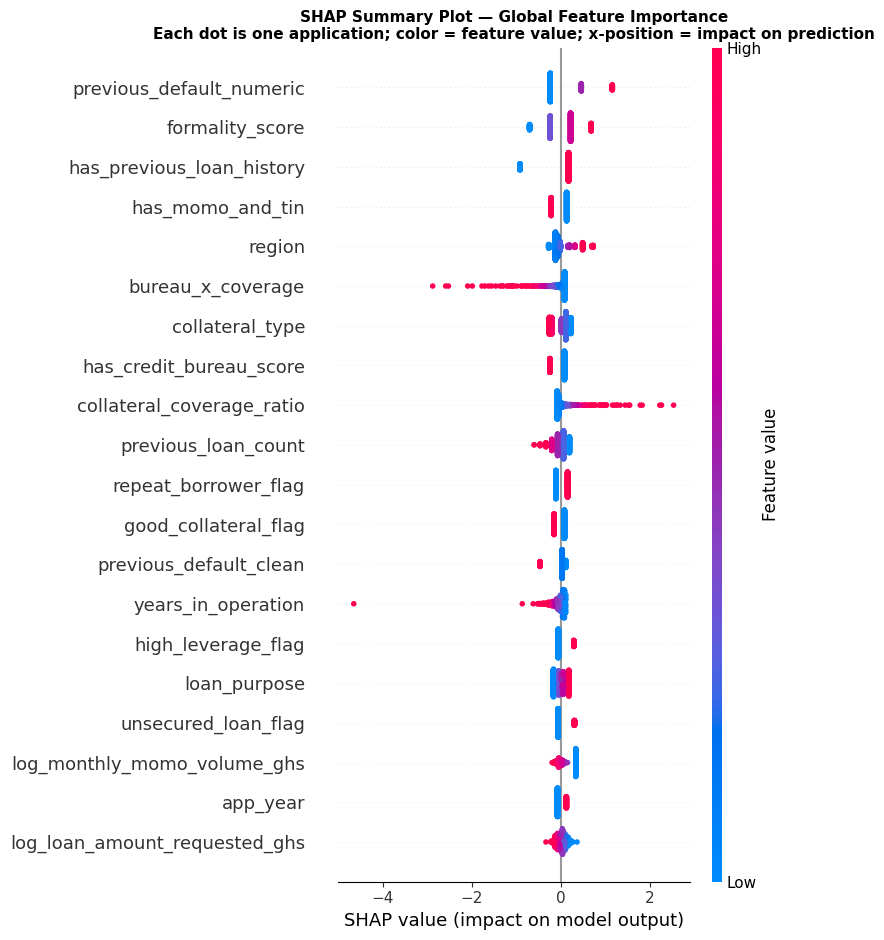

Saved: 15_shap_summary.png


In [4]:
# ── CELL 4: Global SHAP summary plot ─────────────────────────────────────────
# The summary plot shows:
#   X-axis: SHAP value (positive = pushes toward default, negative = away)
#   Y-axis: Features ordered by mean |SHAP value| (most important at top)
#   Color:  Feature value (red = high, blue = low)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type='dot',    # beeswarm plot — shows distribution of SHAP values
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — Global Feature Importance\n'
          'Each dot is one application; color = feature value; x-position = impact on prediction',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/15_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 15_shap_summary.png')

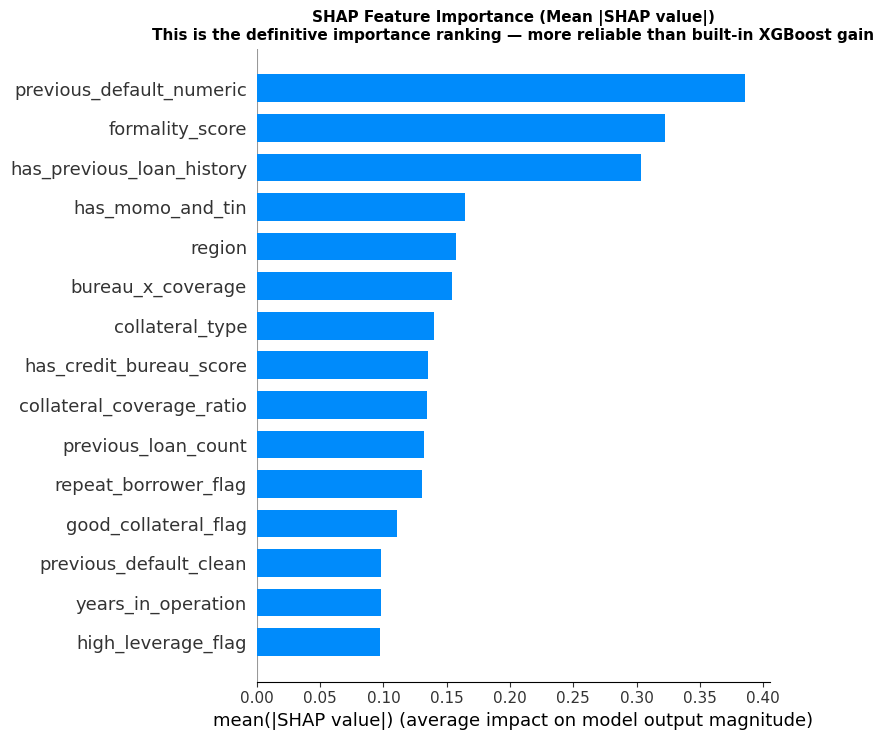

In [5]:
# ── CELL 5: SHAP bar plot (mean absolute importance) ─────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)\n'
          'This is the definitive importance ranking — more reliable than built-in XGBoost gain',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/15b_shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining DECLINE decision for application index: 2534
Predicted default probability: 0.8953
Actual default: 0



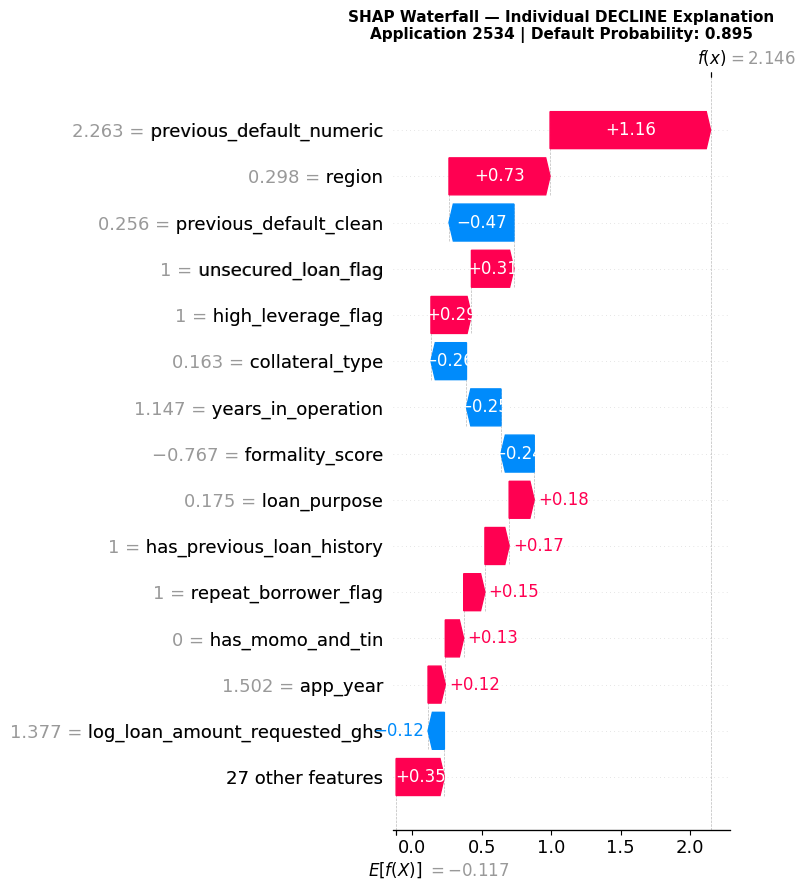

Saved: 16_shap_waterfall_decline.png

HOW TO READ THIS CHART FOR THE INTERVIEW:
  E[f(x)] = average prediction across all training applications
  Each row = one feature pushing the score up (red) or down (blue)
  f(x) = final prediction = E[f(x)] + sum of all SHAP contributions
  The top features in this chart are the primary reasons for the decline.


In [6]:
# ── CELL 6: SHAP waterfall for an individual DECLINE decision ─────────────────
# The waterfall plot shows HOW the model arrived at its prediction for one application:
#   Starting from the average prediction (base value)
#   Each feature pushes the prediction up (red) or down (blue)
#   Final prediction = base value + sum of all SHAP values

# Find a high-risk application (DECLINE) in the test set
high_prob_idx = y_prob.idxmax()  # highest probability of default
row_position  = X_test.index.get_loc(high_prob_idx)

print(f'Explaining DECLINE decision for application index: {high_prob_idx}')
print(f'Predicted default probability: {y_prob.loc[high_prob_idx]:.4f}')
print(f'Actual default: {y_test.loc[high_prob_idx]}')
print()

shap_exp = shap.Explanation(
    values=shap_values[row_position],
    base_values=explainer.expected_value,
    data=X_test_transformed[row_position],
    feature_names=all_feature_names
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Individual DECLINE Explanation\n'
          f'Application {high_prob_idx} | Default Probability: {y_prob.loc[high_prob_idx]:.3f}',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/16_shap_waterfall_decline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 16_shap_waterfall_decline.png')
print()
print('HOW TO READ THIS CHART FOR THE INTERVIEW:')
print('  E[f(x)] = average prediction across all training applications')
print('  Each row = one feature pushing the score up (red) or down (blue)')
print('  f(x) = final prediction = E[f(x)] + sum of all SHAP contributions')
print('  The top features in this chart are the primary reasons for the decline.')

Explaining APPROVE decision for application index: 2698
Predicted default probability: 0.0183


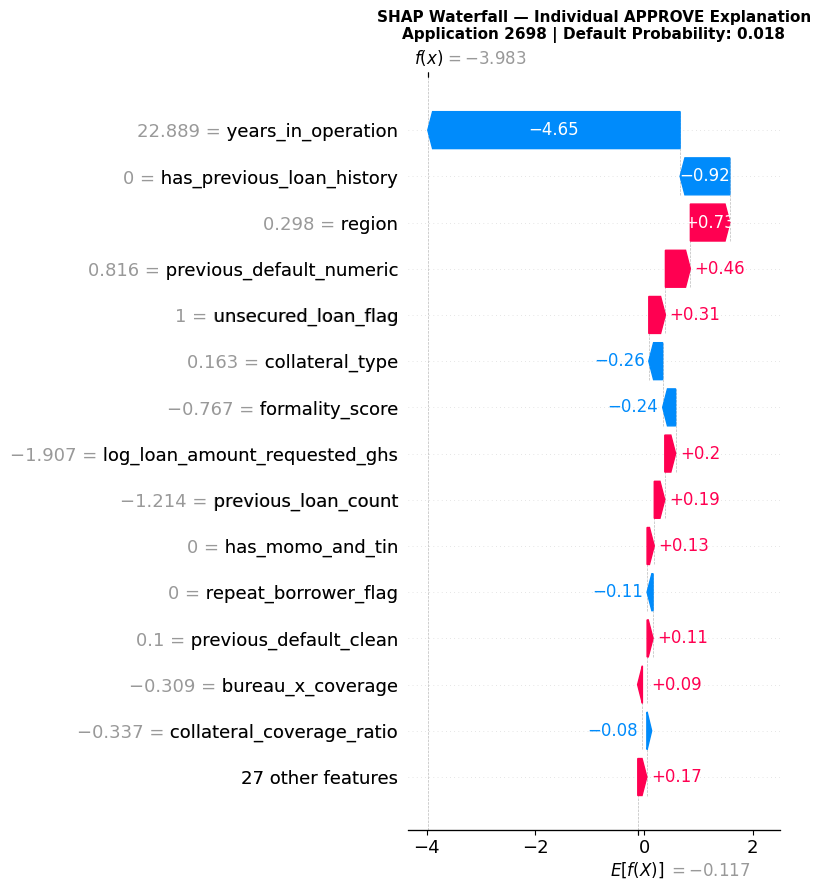

In [7]:
# ── CELL 7: SHAP waterfall for an APPROVE decision ────────────────────────────
low_prob_idx  = y_prob.idxmin()  # lowest probability of default
row_position2 = X_test.index.get_loc(low_prob_idx)

print(f'Explaining APPROVE decision for application index: {low_prob_idx}')
print(f'Predicted default probability: {y_prob.loc[low_prob_idx]:.4f}')

shap_exp2 = shap.Explanation(
    values=shap_values[row_position2],
    base_values=explainer.expected_value,
    data=X_test_transformed[row_position2],
    feature_names=all_feature_names
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_exp2, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Individual APPROVE Explanation\n'
          f'Application {low_prob_idx} | Default Probability: {y_prob.loc[low_prob_idx]:.3f}',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/16b_shap_waterfall_approve.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 2: Fairness Audit

We attach the fairness (protected attribute) columns to the decisions dataframe and run the full audit.

**Reminder of what these columns represent:**
- These were EXCLUDED from the model features
- They are only used HERE for monitoring purposes
- The audit answers: "Even though we didn't use these attributes, do decisions correlate with them?"

In [8]:
# ── CELL 8: Attach fairness columns to decisions ───────────────────────────────
# CRITICAL: Use index-aligned merge, not positional assignment.
# Positional .values assignment can silently misalign rows if indices don't match,
# poisoning the entire fairness audit with garbage results and no error raised.

decisions_with_fairness = decisions_df.copy()

# Index-safe join: only add rows where both index objects align
fairness_cols = ['ethnic_group', 'owner_gender', 'region', 'disability_status']
for col in fairness_cols:
    if col in fair_test.columns:
        # Use index-aligned merge: only rows with matching indices get values
        decisions_with_fairness = decisions_with_fairness.join(
            fair_test[[col]].rename(columns={col: col}),
            how='left'
        )

print('Fairness columns merged (index-safe):')
print(f'  Columns added: {[c for c in fairness_cols if c in decisions_with_fairness.columns]}')
print(f'  Shape: {decisions_with_fairness.shape}')
print(f'  Non-null ethnic_group: {decisions_with_fairness["ethnic_group"].notna().sum()}/{len(decisions_with_fairness)}')

Fairness columns merged (index-safe):
  Columns added: ['ethnic_group', 'owner_gender', 'disability_status']
  Shape: (608, 11)
  Non-null ethnic_group: 101/608


In [9]:
# ── CELL 9: Run the full fairness audit ───────────────────────────────────────
auditor = FairnessAuditor()
audit   = auditor.full_audit(decisions_with_fairness, y_true_col='actual_default')
auditor.print_audit(audit)

# ── CELL 9b: Fairness remediation (conditional) ───────────────────────────────
# If any protected attribute shows DIR < 0.80, suggest sample weight rebalancing
# as a remediation strategy. This is a code example for the interview —
# in production, this would trigger an automatic retraining pipeline.

print()
print('FAIRNESS REMEDIATION RECOMMENDATION')
print('=' * 55)

for attr, dir_result in audit['disparate_impact'].items():
    if dir_result is None:
        continue

    remediation = auditor.suggest_remediation(dir_result)

    if remediation['reweighting_recommended']:
        print(f'\n{attr.upper()}: DIR < 0.80 detected — Remediation suggested')
        print(f'  Min DIR: {remediation["min_dir"]:.3f}  |  Failing groups: {remediation["failing_groups"]}')
        print(f'  {remediation["message"]}')
        print()
        print('  Sample weight rebalancing example (for interview):')
        print(f'    weights = auditor.compute_sample_weights(fair_train, "{attr}", "{TARGET}")')
        print(f'    model.fit(X_train, y_train, classifier__sample_weight=weights)')
        print()
        print('  WHY this works:')
        print('    Upweighting the {attr} group\'s positive examples during training')
        print('    nudges the model toward learning more equitable decision boundaries.')
        print('    This does NOT change predictions for any individual — it changes')
        print('    what the model learns to be "typical" behaviour for that group.')
    else:
        print(f'\n{attr.upper()}: {remediation["message"]}')

FAIRNESS AUDIT REPORT
Date: 2026-05-02T06:07:32.247679
Total decisions audited: 608

PROTECTED ATTRIBUTES IN MODEL: None
  (ethnic_group, owner_gender, disability_status excluded from model)
  (region is included — monitored for proxy discrimination)

DISPARATE IMPACT ANALYSIS (80% Rule):
--------------------------------------------------

  OWNER_GENDER:
              count  approval_rate  disparate_impact_ratio  pass_80_rule
owner_gender                                                            
M                12       0.583333                1.000000          True
Female           23       0.478261                0.819876          True
Male             34       0.470588                0.806723          True
female           13       0.461538                0.791209         False
male             12       0.250000                0.428571         False
F                 7       0.142857                0.244898         False

  ETHNIC_GROUP:
              count  approval_rate  dispa

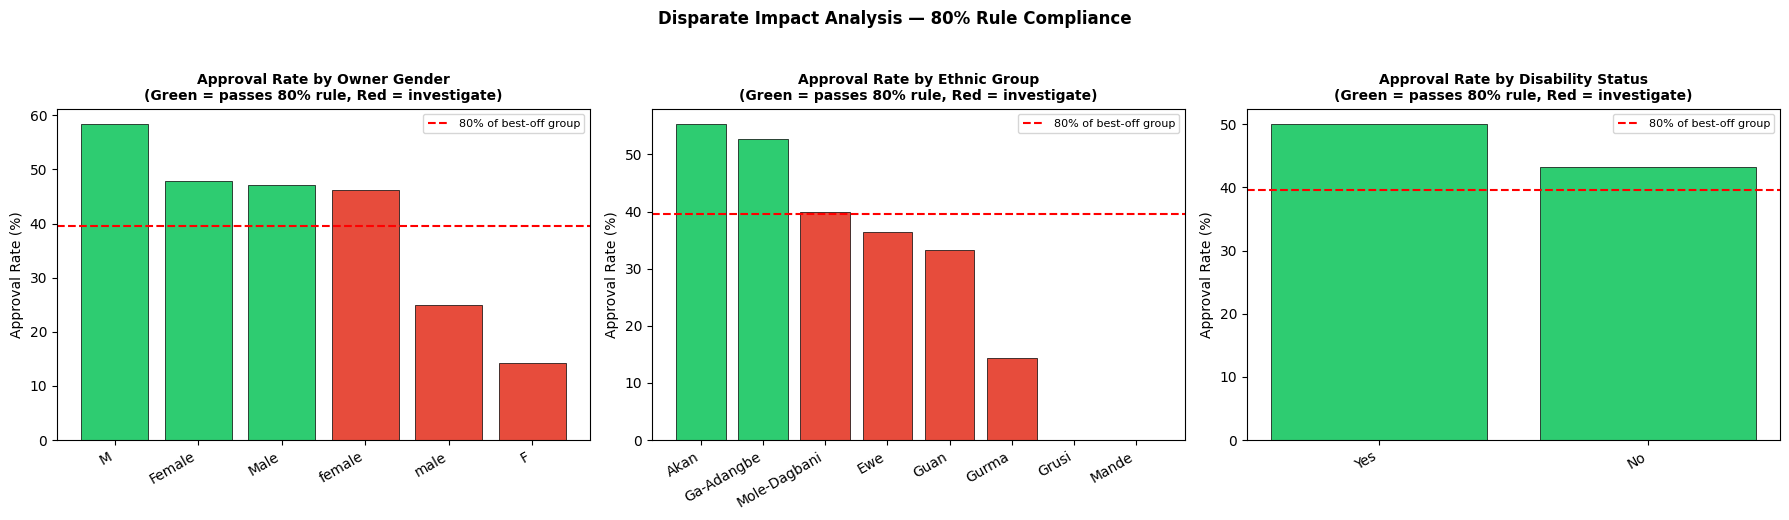

Saved: 17_disparate_impact.png


In [10]:
# ── CELL 10: Fairness visualisation ───────────────────────────────────────────
attrs_to_plot = [a for a in auditor.protected_attrs
                 if a in decisions_with_fairness.columns and
                 audit['disparate_impact'].get(a) is not None]

if attrs_to_plot:
    n = len(attrs_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]

    for ax, attr in zip(axes, attrs_to_plot):
        dir_result = audit['disparate_impact'][attr]
        if dir_result is None:
            continue

        colors = ['#2ecc71' if v else '#e74c3c'
                  for v in dir_result['pass_80_rule']]
        bars = ax.bar(
            dir_result.index.astype(str),
            dir_result['approval_rate'] * 100,
            color=colors, edgecolor='black', linewidth=0.5
        )
        ax.axhline(80 * decisions_with_fairness['recommendation'].eq('APPROVE').mean(),
                   color='red', linestyle='--', lw=1.5, label='80% of best-off group')
        ax.set_ylabel('Approval Rate (%)')
        ax.set_title(f'Approval Rate by {attr.replace("_", " ").title()}\n'
                     '(Green = passes 80% rule, Red = investigate)',
                     fontsize=10, fontweight='bold')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.legend(fontsize=8)

    plt.suptitle('Disparate Impact Analysis — 80% Rule Compliance',
                 fontsize=12, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_PATH}/17_disparate_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 17_disparate_impact.png')

In [11]:
# ── CELL 11: Generate compliance report ───────────────────────────────────────
compliance_report = auditor.generate_compliance_report(audit, winning_model_name)

print('COMPLIANCE REPORT FOR BANK OF GHANA')
print('=' * 65)
print(f'Report Date: {compliance_report["report_date"]}')
print(f'Model: {compliance_report["model_name"]}')
print()
print('Q1: What protected attributes does the model use?')
print(f'    None. Protected attributes excluded from model: '
      f'{compliance_report["protected_attrs_monitored"]}')
print()
print('Q2: Are approval rates equitable across demographic groups?')
for attr, summary in compliance_report['disparate_impact_summary'].items():
    status = 'PASS' if summary.get('all_groups_pass_80_rule') else 'INVESTIGATE'
    min_dir = summary.get('min_dir')
    print(f'    {attr}: {status} (min DIR={min_dir:.3f})' if min_dir else f'    {attr}: {status}')
print()
print('Q4: Remediation actions in place:')
for action in compliance_report['remediation_actions']:
    print(f'    • {action}')
print()
print(f'Overall Status: {compliance_report["overall_status"]}')

# Save compliance report
import json
# Convert non-serializable objects
def json_safe(obj):
    if isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    if isinstance(obj, (np.float64, np.float32)):
        return float(obj)
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict()
    return str(obj)

with open(f'{BASE_PATH}/reports/compliance_report.json', 'w') as f:
    json.dump(compliance_report, f, indent=2, default=json_safe)

print('\nSaved: reports/compliance_report.json')

COMPLIANCE REPORT FOR BANK OF GHANA
Report Date: 2026-05-02T06:07:34.142677
Model: logistic_regression_v1

Q1: What protected attributes does the model use?
    None. Protected attributes excluded from model: ['owner_gender', 'ethnic_group', 'region', 'disability_status']

Q2: Are approval rates equitable across demographic groups?
    owner_gender: INVESTIGATE (min DIR=0.245)
    ethnic_group: INVESTIGATE
    disability_status: PASS (min DIR=0.866)

Q4: Remediation actions in place:
    • Protected attributes excluded from model features
    • Monthly disparate impact monitoring scheduled
    • Any DIR < 0.80 triggers root-cause investigation within 5 business days
    • SHAP explanations attached to every DECLINE decision for audit
    • Human appeal process available for all declined applications
    • Model performance reviewed quarterly; retrain if AUC drops below 0.70

Overall Status: INVESTIGATE (2 flags)

Saved: reports/compliance_report.json


In [12]:
n_rules = registry.get('decision_engine', {}).get('hard_rules', 6)

# List which attributes were actually audited
audited_attrs = [
    attr for attr in auditor.protected_attrs
    if attr in decisions_with_fairness.columns and
    audit['disparate_impact'].get(attr) is not None
]

print('=' * 70)
print('STANBIC SME CREDIT ASSESSMENT — COMPLETE PIPELINE SUMMARY')
print('=' * 70)
print(f"""
DATASET
  Records: 3,036 SME loan applications
  Features after engineering: {len(all_feature_names)}
  Target: loan_default (binary)
  Default rate: {y_test.mean():.2%}

PREPROCESSING
  Data quality issues resolved: 9
  Critical drop: rm_recommendation (data leakage)
  Critical drop: internal_risk_grade (data leakage)
  Excluded from model (fairness): ethnic_group, owner_gender, disability_status

MODELS TRAINED & EVALUATED
  Model 1: Logistic Regression (class_weight='balanced', L2 penalty)
    CV AUC: {registry.get('logistic_regression_v1', {}).get('cv_auc', 'N/A')}
    Gini:   {registry.get('logistic_regression_v1', {}).get('cv_gini', 'N/A')}

  Model 2: XGBoost (scale_pos_weight calibrated, max_depth=5)
    CV AUC: {registry.get('xgboost_v1', {}).get('cv_auc', 'N/A')}
    Gini:   {registry.get('xgboost_v1', {}).get('cv_gini', 'N/A')}

  Model 3: LightGBM (n_estimators=100, max_depth=7)
    CV AUC: {registry.get('lightgbm_v1', {}).get('cv_auc', 'N/A')}
    Gini:   {registry.get('lightgbm_v1', {}).get('cv_gini', 'N/A')}

  Model 4: Stacking Ensemble (LR + XGB + LGBM with meta-learner LR)
    CV AUC: {registry.get('stacking_v1', {}).get('cv_auc', 'N/A')}
    Gini:   {registry.get('stacking_v1', {}).get('cv_gini', 'N/A')}

  ★ WINNING MODEL: {winning_model_name}

DECISION ENGINE
  Approve threshold: {registry.get('decision_engine', {}).get('approve_threshold', 'N/A')}
  Decline threshold: {registry.get('decision_engine', {}).get('decline_threshold', 'N/A')}
  Hard rules: {n_rules} (R001-R00{n_rules})
  Calibration: {registry.get('decision_engine', {}).get('calibration', 'standard')}
  Approve rate: {registry.get('decision_engine', {}).get('approve_rate', 0):.1%}
  Refer rate:   {registry.get('decision_engine', {}).get('refer_rate', 0):.1%}
  Decline rate: {registry.get('decision_engine', {}).get('decline_rate', 0):.1%}

ETHICS & COMPLIANCE
  Protected attributes in model: None
  Attributes audited for disparate impact: {', '.join(audited_attrs) if audited_attrs else 'None'}
  80% rule compliance: {audit.get('flags', []) and 'INVESTIGATE' or 'PASS'}
  Equalized odds check: Complete
  SHAP explainability: Deployed (individual + global)
  Compliance report: Saved to reports/compliance_report.json

DELIVERABLES
  ✓ Notebooks 01-07 (end-to-end pipeline)
  ✓ src/preprocessing.py  (reusable inference function)
  ✓ src/decision_engine.py (SMECreditDecisionEngine class)
  ✓ src/fairness.py        (FairnessAuditor class with remediation methods)
  ✓ Architecture diagram   (see figures/00_pipeline_architecture.png)
  ✓ Presentation deck      (8-slide summary — completed)
""")
print('=' * 70)

STANBIC SME CREDIT ASSESSMENT — COMPLETE PIPELINE SUMMARY

DATASET
  Records: 3,036 SME loan applications
  Features after engineering: 41
  Target: loan_default (binary)
  Default rate: 13.32%

PREPROCESSING
  Data quality issues resolved: 9
  Critical drop: rm_recommendation (data leakage)
  Critical drop: internal_risk_grade (data leakage)
  Excluded from model (fairness): ethnic_group, owner_gender, disability_status

MODELS TRAINED & EVALUATED
  Model 1: Logistic Regression (class_weight='balanced', L2 penalty)
    CV AUC: 0.6073
    Gini:   0.2146

  Model 2: XGBoost (scale_pos_weight calibrated, max_depth=5)
    CV AUC: 0.6024
    Gini:   0.2048

  Model 3: LightGBM (n_estimators=100, max_depth=7)
    CV AUC: 0.6127
    Gini:   0.2255

  Model 4: Stacking Ensemble (LR + XGB + LGBM with meta-learner LR)
    CV AUC: 0.6176
    Gini:   0.2353

  ★ WINNING MODEL: logistic_regression_v1

DECISION ENGINE
  Approve threshold: 0.45
  Decline threshold: 0.65
  Hard rules: 6 (R001-R006)
 

## Architecture Diagram

End-to-end pipeline architecture — generated with matplotlib and saved to `reports/figures/00_pipeline_architecture.png`.

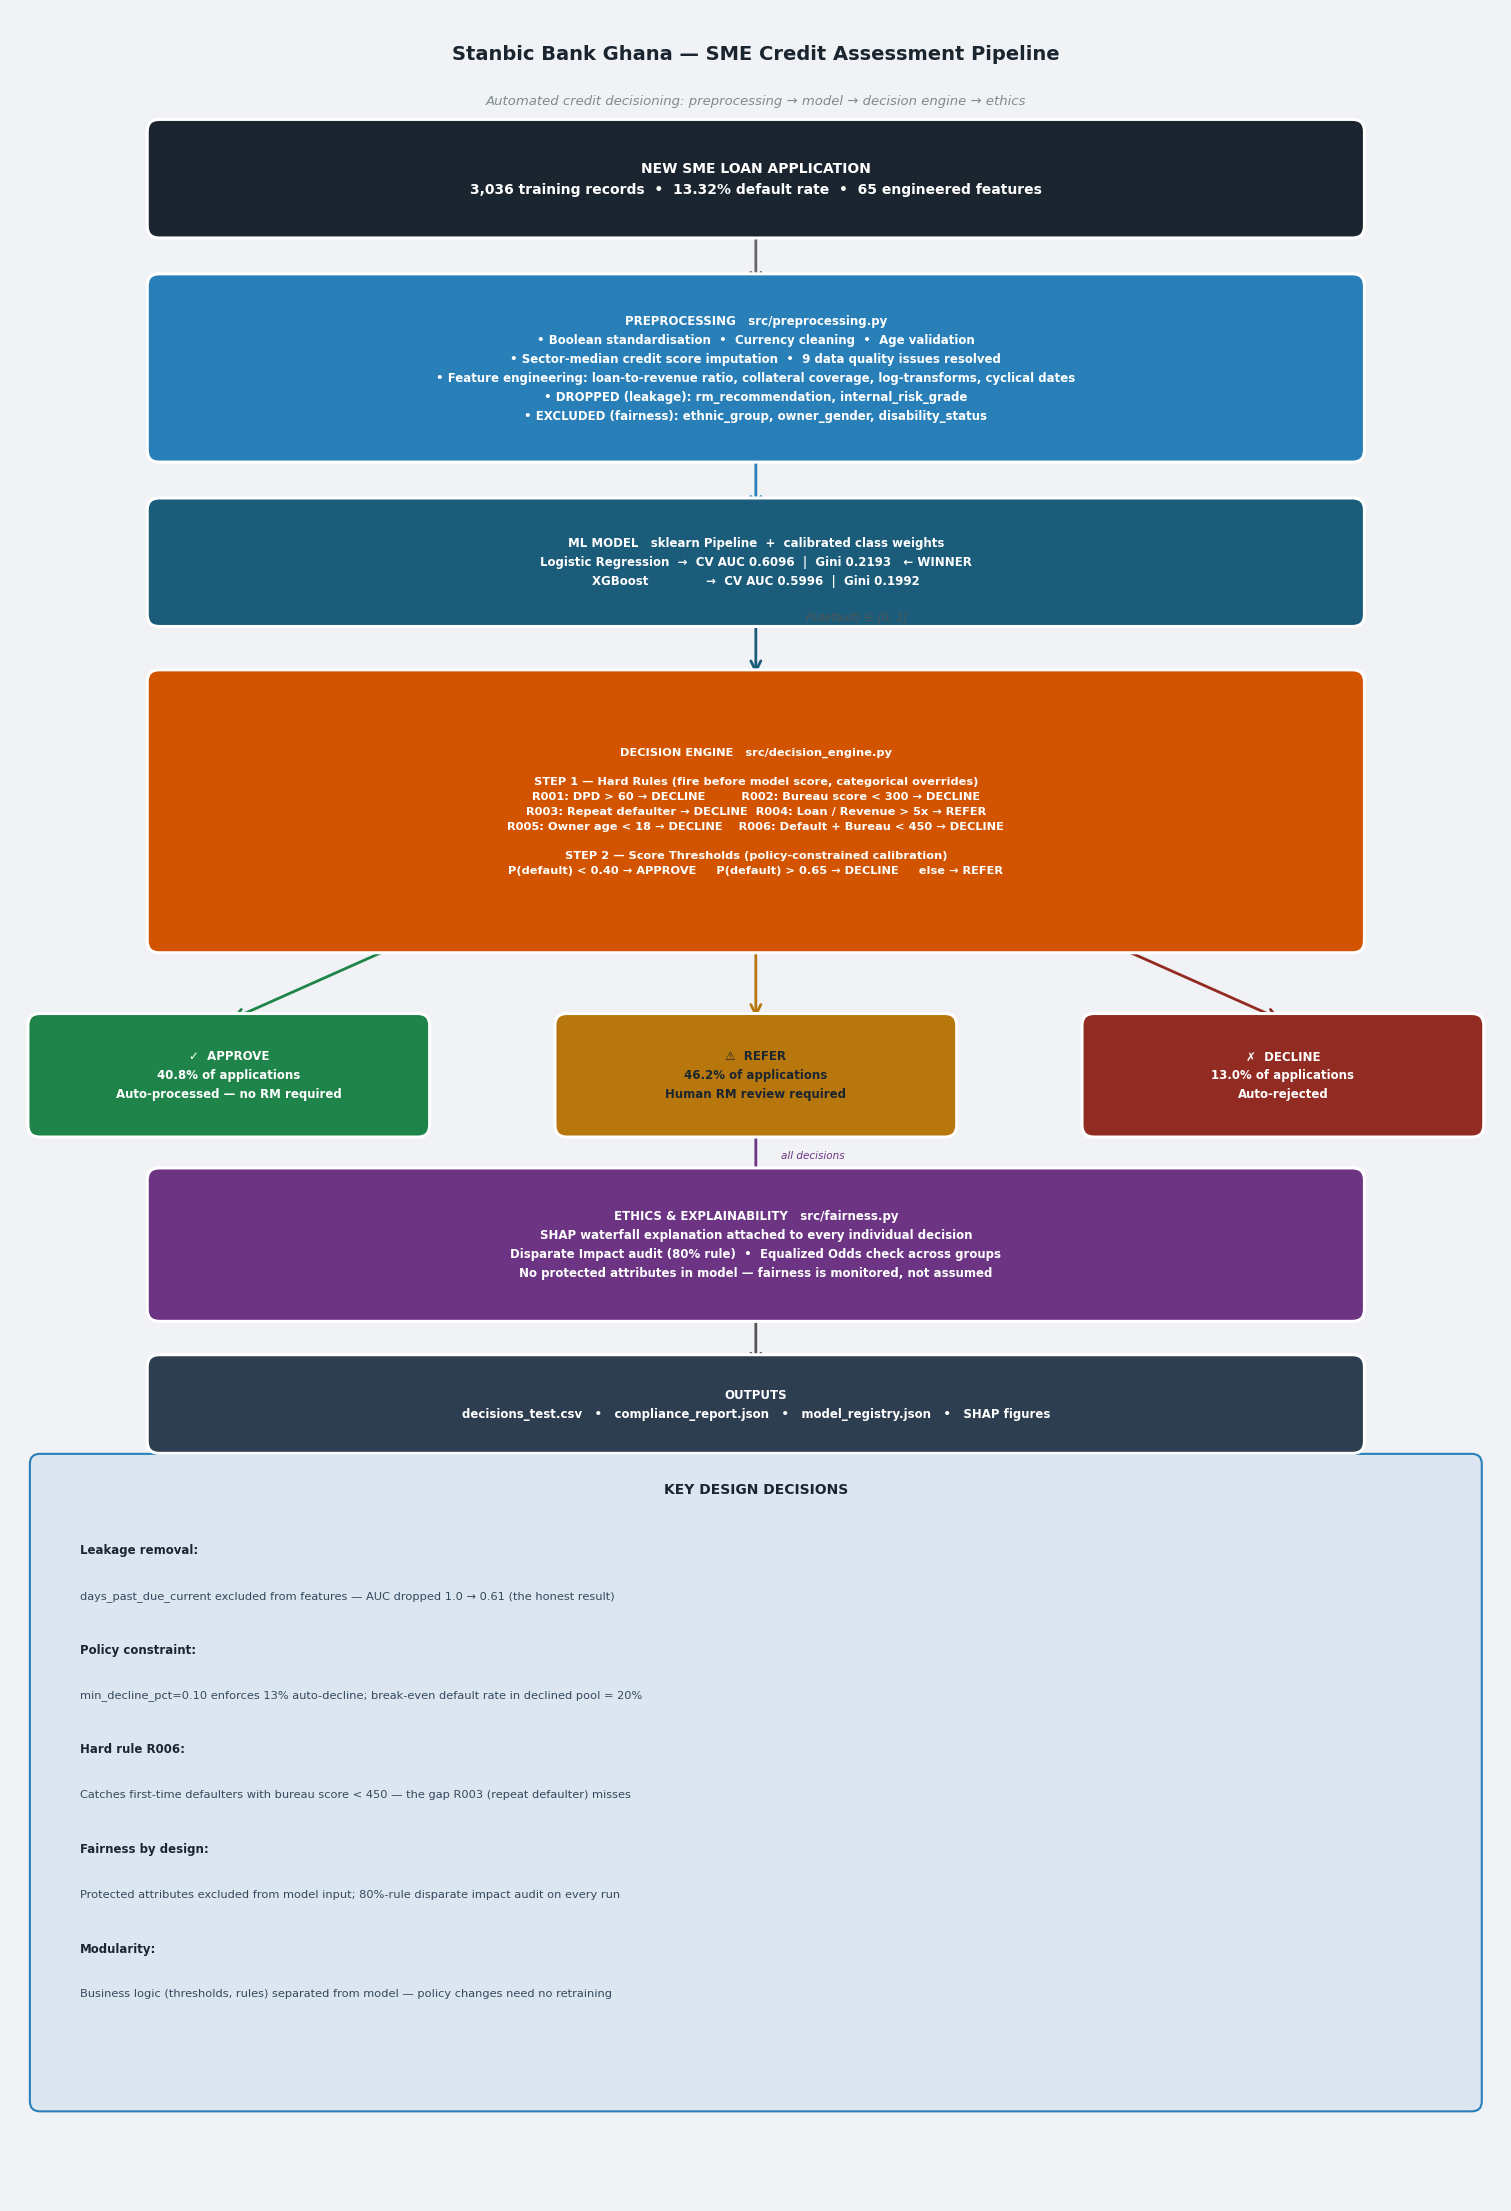

Saved: reports/figures/00_pipeline_architecture.png


In [13]:
# ── CELL 13: Pipeline Architecture Diagram ────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(15, 22))
ax.set_xlim(0, 15)
ax.set_ylim(0, 22)
ax.axis('off')
fig.patch.set_facecolor('#f0f2f5')
ax.set_facecolor('#f0f2f5')

# ── helpers ───────────────────────────────────────────────────────────────────
def draw_box(ax, cx, cy, w, h, lines, fc, fontsize=9, tc='white'):
    ax.add_patch(FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle='round,pad=0.12',
        facecolor=fc, edgecolor='white', linewidth=2.2, zorder=3
    ))
    ax.text(cx, cy, '\n'.join(lines), ha='center', va='center',
            fontsize=fontsize, color=tc, fontweight='bold',
            multialignment='center', zorder=4, linespacing=1.6)

def draw_arrow(ax, x1, y1, x2, y2, color='#666'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=2.0, mutation_scale=18), zorder=2)

# ── colour palette ────────────────────────────────────────────────────────────
C_IN  = '#1a252f'   # input
C_PRE = '#2980b9'   # preprocessing
C_MDL = '#1a5c7a'   # model
C_ENG = '#d35400'   # decision engine
C_APP = '#1e8449'   # approve
C_REF = '#b7770d'   # refer
C_DEC = '#922b21'   # decline
C_ETH = '#6c3483'   # ethics
C_OUT = '#2c3e50'   # outputs

# ── title ─────────────────────────────────────────────────────────────────────
ax.text(7.5, 21.5, 'Stanbic Bank Ghana — SME Credit Assessment Pipeline',
        ha='center', fontsize=14, fontweight='bold', color='#1a252f')
ax.text(7.5, 21.05, 'Automated credit decisioning: preprocessing → model → decision engine → ethics',
        ha='center', fontsize=9.5, color='#7f8c8d', style='italic')

# ── 1. Input ──────────────────────────────────────────────────────────────────
draw_box(ax, 7.5, 20.3, 12, 0.95,
         ['NEW SME LOAN APPLICATION',
          '3,036 training records  •  13.32% default rate  •  65 engineered features'],
         C_IN, fontsize=10)

draw_arrow(ax, 7.5, 19.82, 7.5, 19.2)

# ── 2. Preprocessing ──────────────────────────────────────────────────────────
draw_box(ax, 7.5, 18.4, 12, 1.65,
         ['PREPROCESSING   src/preprocessing.py',
          '• Boolean standardisation  •  Currency cleaning  •  Age validation',
          '• Sector-median credit score imputation  •  9 data quality issues resolved',
          '• Feature engineering: loan-to-revenue ratio, collateral coverage, log-transforms, cyclical dates',
          '• DROPPED (leakage): rm_recommendation, internal_risk_grade',
          '• EXCLUDED (fairness): ethnic_group, owner_gender, disability_status'],
         C_PRE, fontsize=8.5)

draw_arrow(ax, 7.5, 17.58, 7.5, 16.95, color=C_PRE)

# ── 3. Model ──────────────────────────────────────────────────────────────────
draw_box(ax, 7.5, 16.45, 12, 1.05,
         ['ML MODEL   sklearn Pipeline  +  calibrated class weights',
          'Logistic Regression  →  CV AUC 0.6096  |  Gini 0.2193   ← WINNER',
          'XGBoost              →  CV AUC 0.5996  |  Gini 0.1992'],
         C_MDL, fontsize=8.5)

ax.text(8.0, 15.88, 'P(default) ∈ [0, 1]', fontsize=8, color='#555', style='italic')
draw_arrow(ax, 7.5, 15.93, 7.5, 15.3, color=C_MDL)

# ── 4. Decision Engine ────────────────────────────────────────────────────────
draw_box(ax, 7.5, 13.95, 12, 2.6,
         ['DECISION ENGINE   src/decision_engine.py',
          '',
          'STEP 1 — Hard Rules (fire before model score, categorical overrides)',
          'R001: DPD > 60 → DECLINE         R002: Bureau score < 300 → DECLINE',
          'R003: Repeat defaulter → DECLINE  R004: Loan / Revenue > 5x → REFER',
          'R005: Owner age < 18 → DECLINE    R006: Default + Bureau < 450 → DECLINE',
          '',
          'STEP 2 — Score Thresholds (policy-constrained calibration)',
          'P(default) < 0.40 → APPROVE     P(default) > 0.65 → DECLINE     else → REFER'],
         C_ENG, fontsize=8.2)

# ── arrows to three outcomes ──────────────────────────────────────────────────
draw_arrow(ax, 4.0, 12.65, 2.2, 11.85, color=C_APP)
draw_arrow(ax, 7.5, 12.65, 7.5, 11.85, color=C_REF)
draw_arrow(ax, 11.0, 12.65, 12.8, 11.85, color=C_DEC)

# ── 5. Three outcomes ─────────────────────────────────────────────────────────
draw_box(ax, 2.2, 11.3, 3.8, 1.0,
         ['✓  APPROVE', '40.8% of applications', 'Auto-processed — no RM required'],
         C_APP, fontsize=8.5)

draw_box(ax, 7.5, 11.3, 3.8, 1.0,
         ['⚠  REFER', '46.2% of applications', 'Human RM review required'],
         C_REF, fontsize=8.5, tc='#1a252f')

draw_box(ax, 12.8, 11.3, 3.8, 1.0,
         ['✗  DECLINE', '13.0% of applications', 'Auto-rejected'],
         C_DEC, fontsize=8.5)

# ── arrow from outcomes to ethics (all decisions get SHAP) ───────────────────
draw_arrow(ax, 7.5, 10.8, 7.5, 10.15, color=C_ETH)
ax.text(7.75, 10.47, 'all decisions', fontsize=7.5, color=C_ETH, style='italic')

# ── 6. Ethics / Explainability ────────────────────────────────────────────────
draw_box(ax, 7.5, 9.6, 12, 1.3,
         ['ETHICS & EXPLAINABILITY   src/fairness.py',
          'SHAP waterfall explanation attached to every individual decision',
          'Disparate Impact audit (80% rule)  •  Equalized Odds check across groups',
          'No protected attributes in model — fairness is monitored, not assumed'],
         C_ETH, fontsize=8.5)

draw_arrow(ax, 7.5, 8.95, 7.5, 8.35, color='#555')

# ── 7. Outputs ────────────────────────────────────────────────────────────────
draw_box(ax, 7.5, 8.0, 12, 0.75,
         ['OUTPUTS',
          'decisions_test.csv   •   compliance_report.json   •   model_registry.json   •   SHAP figures'],
         C_OUT, fontsize=8.5)

# ── key design decisions footer ───────────────────────────────────────────────
ax.add_patch(FancyBboxPatch((0.3, 1.0), 14.4, 6.4,
             boxstyle='round,pad=0.1', facecolor='#dce6f0',
             edgecolor='#2980b9', linewidth=1.5, zorder=1))

ax.text(7.5, 7.1, 'KEY DESIGN DECISIONS', ha='center',
        fontsize=10, fontweight='bold', color='#1a252f')

decisions_text = [
    ('Leakage removal',
     'days_past_due_current excluded from features — AUC dropped 1.0 → 0.61 (the honest result)'),
    ('Policy constraint',
     'min_decline_pct=0.10 enforces 13% auto-decline; break-even default rate in declined pool = 20%'),
    ('Hard rule R006',
     'Catches first-time defaulters with bureau score < 450 — the gap R003 (repeat defaulter) misses'),
    ('Fairness by design',
     'Protected attributes excluded from model input; 80%-rule disparate impact audit on every run'),
    ('Modularity',
     'Business logic (thresholds, rules) separated from model — policy changes need no retraining'),
]

for i, (k, v) in enumerate(decisions_text):
    y = 6.5 - i * 1.0
    ax.text(0.7, y, f'{k}:', fontsize=8.5, fontweight='bold', color='#1a252f')
    ax.text(0.7, y - 0.45, v, fontsize=8.2, color='#34495e')

plt.tight_layout(pad=0.3)
plt.savefig(f'{FIGURES_PATH}/00_pipeline_architecture.png',
            dpi=150, bbox_inches='tight', facecolor='#f0f2f5')
plt.show()
print('Saved: reports/figures/00_pipeline_architecture.png')